# PDSPL and DSPL Cosmology Forecast (Fixed $\beta_{\rm E}$ scatter)

In [1]:
# =============================================================================
# Forecast for Flat w0waCDM cosmology with the dissimilarity scatter
# coefficients FIXED to the quadrature-fit values calibrated in notebook 03.
# =============================================================================

In [2]:
# ── Cell 1: Imports ──────────────────────────────────────────────────────────
import pickle
import os
import numpy as np
from astropy.cosmology import Flatw0waCDM
from matplotlib import pyplot as plt
import corner
import matplotlib.lines as mlines

from pdspl_utils.inference import draw_lens_from_given_zs, run_dspl_inference
from pdspl_utils.pairing  import eval_scatter_model
from pdspl_utils.plotting import plot_dspl_corner

POSTERIOR_DIRECTORY = "../data/posteriors/forecast_w0waCDM_fixed_scatter"
FIGURE_DIRECTORY    = "../figures/forecasts/w0waCDM_fixed_scatter"
os.makedirs(POSTERIOR_DIRECTORY, exist_ok=True)
os.makedirs(FIGURE_DIRECTORY,    exist_ok=True)

In [3]:
# ── Cell 2: Load pre-computed pairing results ─────────────────────────────────
with open("../data/samples/pdspl_samples_with_pairs.pkl", "rb") as f:
    pdspl_samples = pickle.load(f)

In [4]:
# ── Cell 3: Ground truth and cosmology ───────────────────────────────────────
truth = {
    "h0": 70.0, "om": 0.3, "w0": -1.0, "wa": 0.0,
    "lambda_int":  1.0,  "lambda_sigma": 0.05,
    "gamma_pl":    2.0,  "gamma_sigma":  0.16,
}
fixed_params = {"h0": 70.0}
cosmo_true   = Flatw0waCDM(H0=truth["h0"], Om0=truth["om"], w0=truth["w0"], wa=truth["wa"])

## Setup the Sample and Priors

In [5]:
# ── Cell 4: Build scenario dictionary ────────────────────────────────────────
redshift_errors_rel = {
    "DSPL":                     0.0001,
    "lsst_y1":                  0.03,
    "lsst_y10":                 0.03,
    "lsst_4most_spec-z":        0.0001,
    "lsst_4most_spec-z_sigma_v": 0.0001,
}

scenarios = {}
for key in pdspl_samples:
    pa = pdspl_samples[key]["pairs_analysis"]
    scenarios[key] = {
        "name":                   f"PDSPL ({pdspl_samples[key]['name']})",
        "down_sampling":          len(pa["pairs_table"]) / 2000,
        "num_lenses":             len(pa["pairs_table"]),
        "color":                  pdspl_samples[key]["color"],
        "coeffs":                 pa["scatter_vs_dissimilarity_fit_coeffs"],
        "fit_type":               pa["scatter_vs_dissimilarity_fit_type"],
        "pairs_table":            pa["pairs_table"],
        "pairs_table_with_errors": pa["pairs_table_with_errors"],
        "sigma_beta":             pa["scatter_in_beta_E"],
        "redshift_error_rel":     redshift_errors_rel[key],
        "backend_path":           os.path.join(POSTERIOR_DIRECTORY, f"{key}.h5"),
    }

# Synthetic DSPL scenario (500 idealised lenses, no intermediate source mass)
scenarios["DSPL"] = {
    "name":               "DSPL (500 lenses)",
    "down_sampling":      1,
    "num_lenses":         500,
    "color":              "#1f77b4",
    "sigma_beta":         0.00,
    "redshift_error_rel": redshift_errors_rel["DSPL"],
    "backend_path":       os.path.join(POSTERIOR_DIRECTORY, "DSPL.h5"),
}

In [6]:
# ── Cell 5: Generate Asimov mock datasets ────────────────────────────────────
print(f"{'SCENARIO':<60} | {'N_LENS':<10} | STATUS")
print("-" * 85)

for key, sc in scenarios.items():
    num_samples = int(sc["num_lenses"] / sc["down_sampling"])
    kwargs_list = []

    if key == "DSPL":
        for _ in range(num_samples):
            z_lens = np.random.normal(loc=0.5, scale=0.1)
            z1     = np.random.uniform(low=z_lens + 0.1, high=3.0)
            z2     = np.random.uniform(low=z1    + 0.1, high=3.0)

            sigma_beta_meas, sigma_beta_los = 0.01, 0.01
            sigma_meas_rel = np.sqrt(sigma_beta_meas ** 2 + sigma_beta_los ** 2)

            kwargs_list.append(draw_lens_from_given_zs(
                z_lens=z_lens, z1=z1, z2=z2,
                lambda_mst_mean=truth["lambda_int"], lambda_mst_sigma=truth["lambda_sigma"],
                gamma_pl_mean=truth["gamma_pl"],     gamma_pl_sigma=truth["gamma_sigma"],
                sigma_beta_intrinsic=sc["sigma_beta"],
                sigma_meas_rel=sigma_meas_rel,
                dissimilarity=0.0,
                down_sampling=sc["down_sampling"],
                with_noise=False,
                cosmo=cosmo_true,
                redshift_error_rel=sc["redshift_error_rel"],
            ))
    else:
        pairs_table       = sc["pairs_table"]
        pairs_table_err   = sc["pairs_table_with_errors"]
        coeffs            = sc["coeffs"]
        fit_type          = sc["fit_type"]
        random_indices    = np.random.choice(len(pairs_table), size=num_samples, replace=False)

        for i in random_indices:
            z_lens       = pairs_table["z_D"][i]
            z1           = pairs_table["z_S1"][i]
            z2           = pairs_table["z_S2"][i]
            dissimilarity = pairs_table_err["dissimilarity"][i]

            # ── use eval_scatter_model (not np.polyval) ──────────────────
            sigma_beta_intrinsic = eval_scatter_model(coeffs, fit_type, dissimilarity)

            sigma_beta_meas, sigma_beta_los = 0.01, 0.01
            sigma_meas_rel = np.sqrt(sigma_beta_meas ** 2 + sigma_beta_los ** 2)

            kwargs_list.append(draw_lens_from_given_zs(
                z_lens=z_lens, z1=z1, z2=z2,
                lambda_mst_mean=truth["lambda_int"], lambda_mst_sigma=truth["lambda_sigma"],
                gamma_pl_mean=truth["gamma_pl"],     gamma_pl_sigma=truth["gamma_sigma"],
                sigma_beta_intrinsic=sigma_beta_intrinsic,
                sigma_meas_rel=sigma_meas_rel,
                dissimilarity=dissimilarity,
                down_sampling=sc["down_sampling"],
                with_noise=False,
                cosmo=cosmo_true,
                redshift_error_rel=sc["redshift_error_rel"],
            ))

    sc["kwargs_list"] = kwargs_list
    print(f"{sc['name']:<60} | {num_samples:<10} | GENERATED")

original_keys = list(scenarios.keys())

SCENARIO                                                     | N_LENS     | STATUS
-------------------------------------------------------------------------------------
PDSPL (LSST Y1)                                              | 2000       | GENERATED
PDSPL (LSST Y10)                                             | 2000       | GENERATED
PDSPL (4MOST ($z^{\rm spec}$))                               | 2000       | GENERATED
PDSPL (4MOST ($z^{\rm spec}$ + $\sigma_{v, D}$))             | 2000       | GENERATED
DSPL (500 lenses)                                            | 500        | GENERATED


Note: N_LENS above doesn't have to match the actual sample size as we are effectively using the down-sampling factor with reduced scatter to simulate the effect of a larger sample size.

## Run the Forecast Inference

### a. Uniform Prior Forecasts

In [7]:

# ── Cell 6: MCMC inference — uniform priors ───────────────────────────────────
my_guess = {
    "om": 0.3, "w0": -1.0, "wa": 0.0,
    "lambda_int":  1.0,  "lambda_sigma": 0.05,
    "gamma_pl":    2.0,  "gamma_sigma":  0.16,
}
my_spreads = {
    "om": 0.1, "w0": 0.1, "wa": 0.1,
    "lambda_int":  0.1, "lambda_sigma": 0.01,
    "gamma_pl":    0.1, "gamma_sigma":  0.01,
}
my_priors = {
    "h0":           ("uniform", 50.0, 90.0),
    "om":           ("uniform",  0.0,  1.0),
    "w0":           ("uniform", -3.0,  0.0),
    "wa":           ("uniform", -5.0,  5.0),
    "lambda_int":   ("uniform",  0.8,  1.2),
    "lambda_sigma": ("uniform",  0.0,  0.2),
    "gamma_pl":     ("uniform",  1.0,  3.0),
    "gamma_sigma":  ("uniform",  0.0,  0.5),
}

print("\n--- Starting MCMC (uniform priors) ---")
param_labels = None

for key, sc in scenarios.items():
    if "kwargs_list" not in sc:
        continue

    print(f"\nRunning: {sc['name']}")

    # Build fixed_params for this scenario:
    # beta_c0 = c0_floor, beta_c1 = c1_slope (from quadrature fit)
    fixed_params_sc = fixed_params.copy()
    if key == "DSPL":
        fixed_params_sc["beta_c0"] = 0.0
        fixed_params_sc["beta_c1"] = 0.0
        fixed_params_sc["beta_c2"] = 0.0
    else:
        coeffs   = sc["coeffs"]          # [c1_slope, c0_floor]
        fixed_params_sc["beta_c0"] = coeffs[1]   # floor
        fixed_params_sc["beta_c1"] = coeffs[0]   # slope
        fixed_params_sc["beta_c2"] = 0.0

    samples, labels = run_dspl_inference(
        sc["kwargs_list"],
        n_walkers=64, n_steps=2000, n_burn=500,
        initial_guess=my_guess,
        fixed_params=fixed_params_sc,
        initial_scatter=my_spreads,
        priors=my_priors,
        backend_path=sc["backend_path"],
    )
    sc["samples"] = samples
    param_labels  = labels
    print(f"  → {sc['name']} DONE")


--- Starting MCMC (uniform priors) ---

Running: PDSPL (LSST Y1)
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c0', 'beta_c1', 'beta_c2']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']


100%|██████████| 2000/2000 [11:01<00:00,  3.02it/s]


  → PDSPL (LSST Y1) DONE

Running: PDSPL (LSST Y10)
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c0', 'beta_c1', 'beta_c2']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']


100%|██████████| 2000/2000 [11:16<00:00,  2.96it/s]


  → PDSPL (LSST Y10) DONE

Running: PDSPL (4MOST ($z^{\rm spec}$))
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c0', 'beta_c1', 'beta_c2']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']


...

  → PDSPL (4MOST ($z^{\rm spec}$)) DONE

Running: PDSPL (4MOST ($z^{\rm spec}$ + $\sigma_{v, D}$))
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c0', 'beta_c1', 'beta_c2']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']


100%|██████████| 2000/2000 [08:12<00:00,  4.06it/s]


  → PDSPL (4MOST ($z^{\rm spec}$ + $\sigma_{v, D}$)) DONE

Running: DSPL (500 lenses)
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c0', 'beta_c1', 'beta_c2']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']


100%|██████████| 2000/2000 [04:03<00:00,  8.22it/s]

  → DSPL (500 lenses) DONE


### b. Gaussian Prior Forecasts

In [8]:
# ── Cell 7: Ωm Gaussian-prior variant ────────────────────────────────────────
my_priors_om = my_priors.copy()
my_priors_om["om"] = ("gaussian", 0.3, 0.05)

print("\n--- Starting MCMC (Ωm prior) ---")
for key in original_keys:
    key_prior = key + "_om_prior"
    scenarios[key_prior] = scenarios[key].copy()
    scenarios[key_prior]["name"]         += r" + $\Omega_m$ Prior"
    scenarios[key_prior]["backend_path"]  = os.path.join(
        POSTERIOR_DIRECTORY, f"{key_prior}.h5"
    )

for key in original_keys:
    key_prior = key + "_om_prior"
    sc = scenarios[key_prior]
    if "kwargs_list" not in sc:
        continue

    print(f"\nRunning: {sc['name']}")

    fixed_params_sc = fixed_params.copy()
    if key == "DSPL":
        fixed_params_sc["beta_c0"] = 0.0
        fixed_params_sc["beta_c1"] = 0.0
        fixed_params_sc["beta_c2"] = 0.0
    else:
        coeffs = scenarios[key]["coeffs"]
        fixed_params_sc["beta_c0"] = coeffs[1]
        fixed_params_sc["beta_c1"] = coeffs[0]
        fixed_params_sc["beta_c2"] = 0.0

    samples, _ = run_dspl_inference(
        sc["kwargs_list"],
        n_walkers=64, n_steps=2000, n_burn=500,
        initial_guess=my_guess,
        fixed_params=fixed_params_sc,
        initial_scatter=my_spreads,
        priors=my_priors_om,
        backend_path=sc["backend_path"],
    )
    sc["samples"] = samples
    print(f"  → {sc['name']} DONE")


--- Starting MCMC (Ωm prior) ---

Running: PDSPL (LSST Y1) + $\Omega_m$ Prior
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c0', 'beta_c1', 'beta_c2']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']


100%|██████████| 2000/2000 [11:45<00:00,  2.83it/s]


  → PDSPL (LSST Y1) + $\Omega_m$ Prior DONE

Running: PDSPL (LSST Y10) + $\Omega_m$ Prior
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c0', 'beta_c1', 'beta_c2']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']


100%|██████████| 2000/2000 [12:02<00:00,  2.77it/s]


  → PDSPL (LSST Y10) + $\Omega_m$ Prior DONE

Running: PDSPL (4MOST ($z^{\rm spec}$)) + $\Omega_m$ Prior
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c0', 'beta_c1', 'beta_c2']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']


...

  → PDSPL (4MOST ($z^{\rm spec}$)) + $\Omega_m$ Prior DONE

Running: PDSPL (4MOST ($z^{\rm spec}$ + $\sigma_{v, D}$)) + $\Omega_m$ Prior
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c0', 'beta_c1', 'beta_c2']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']


100%|██████████| 2000/2000 [09:01<00:00,  3.69it/s]


  → PDSPL (4MOST ($z^{\rm spec}$ + $\sigma_{v, D}$)) + $\Omega_m$ Prior DONE

Running: DSPL (500 lenses) + $\Omega_m$ Prior
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c0', 'beta_c1', 'beta_c2']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']


100%|██████████| 2000/2000 [04:20<00:00,  7.68it/s]

  → DSPL (500 lenses) + $\Omega_m$ Prior DONE


## Plotting the Forecast Results

In [9]:
# ── Cell 8: Plotting ─────────────────────────────────────────────────────────
latex_labels = {
    "om":           r"$\Omega_{\rm m}$",
    "w0":           r"$w_0$",
    "wa":           r"$w_a$",
    "lambda_int":   r"$\overline{\lambda}_{\rm MST}$",
    "gamma_pl":     r"$\overline{\gamma}_{\rm pl}$",
    "gamma_sigma":  r"$\sigma({\gamma}_{\rm pl})$",
    "lambda_sigma": r"$\sigma({\lambda}_{\rm MST})$",
}
custom_ranges = [
    (0, 1), (-2, 0), (-3, 3),
    (truth["lambda_int"] - 0.1, truth["lambda_int"] + 0.1),
    (0.0, 0.10),
    (truth["gamma_pl"]  - 0.1, truth["gamma_pl"]  + 0.1),
    (0.12, 0.20),
]

###  a. All Scenarios Corner Plot -- Uniform Priors

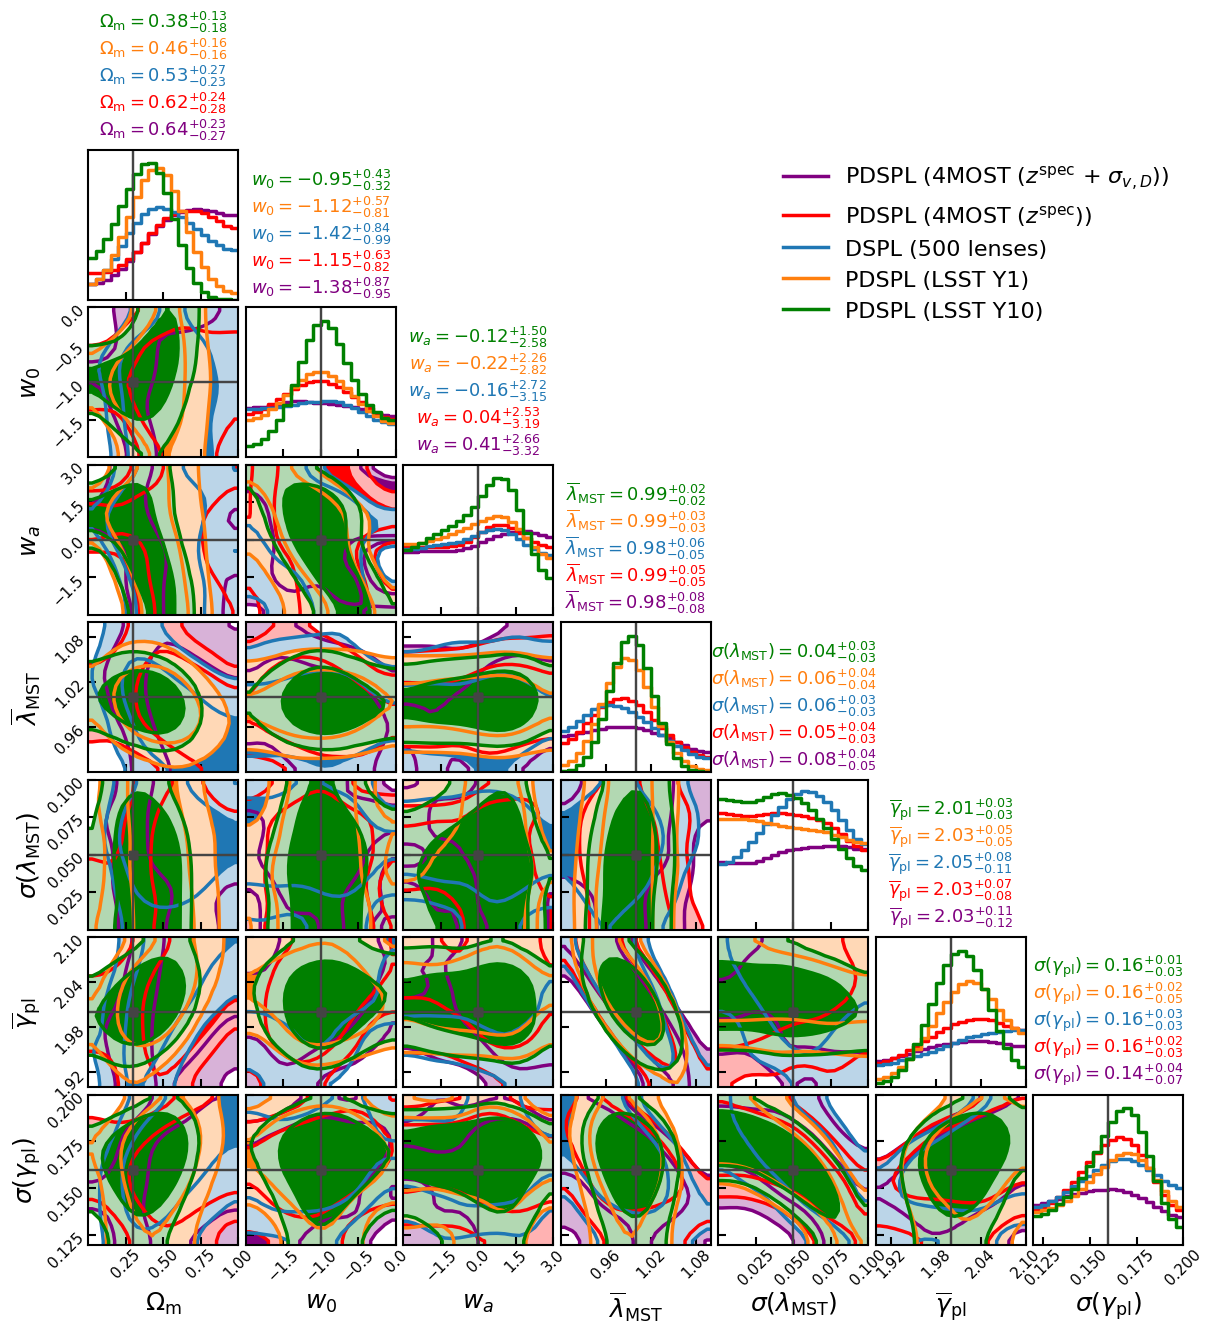

In [10]:
scenarios_to_plot = [
    'lsst_4most_spec-z_sigma_v', 
    'lsst_4most_spec-z', 
    'DSPL', 
    'lsst_y1', 
    'lsst_y10'
]

fig = plot_dspl_corner(
    scenarios=scenarios, 
    truth=truth, 
    fixed_params=fixed_params, 
    scenarios_to_plot=scenarios_to_plot, 
    custom_ranges=custom_ranges, 
    latex_labels=latex_labels, 
    figsize=(12, 12),
    show_multiple_titles=True,
)

plt.show()

###  b. DSPL, LSST Y1, and LSST Y10 Scatter Plot -- Uniform Priors

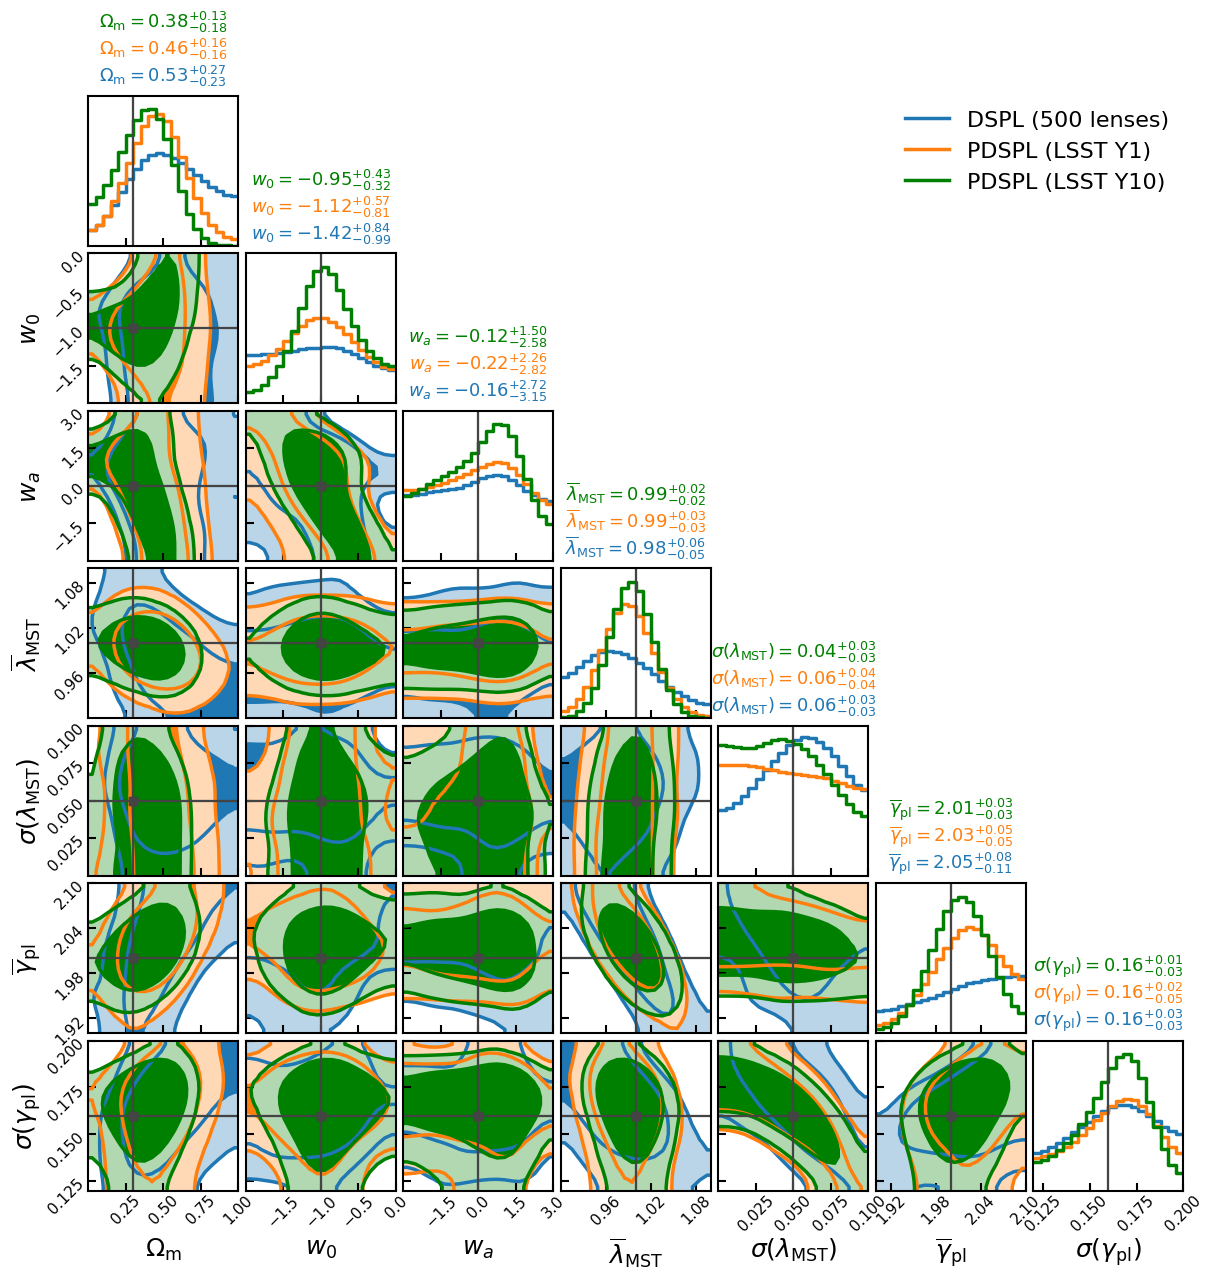

In [11]:
scenarios_to_plot = [
    'DSPL', 
    'lsst_y1', 
    'lsst_y10'
]

fig = plot_dspl_corner(
    scenarios=scenarios, 
    truth=truth, 
    fixed_params=fixed_params, 
    scenarios_to_plot=scenarios_to_plot,
    custom_ranges=custom_ranges,
    latex_labels=latex_labels,
    figsize=(12, 12),
    show_multiple_titles=True,
)

plt.show()

###  c. All Scenarios Corner Plot -- $\Omega_m$ Prior

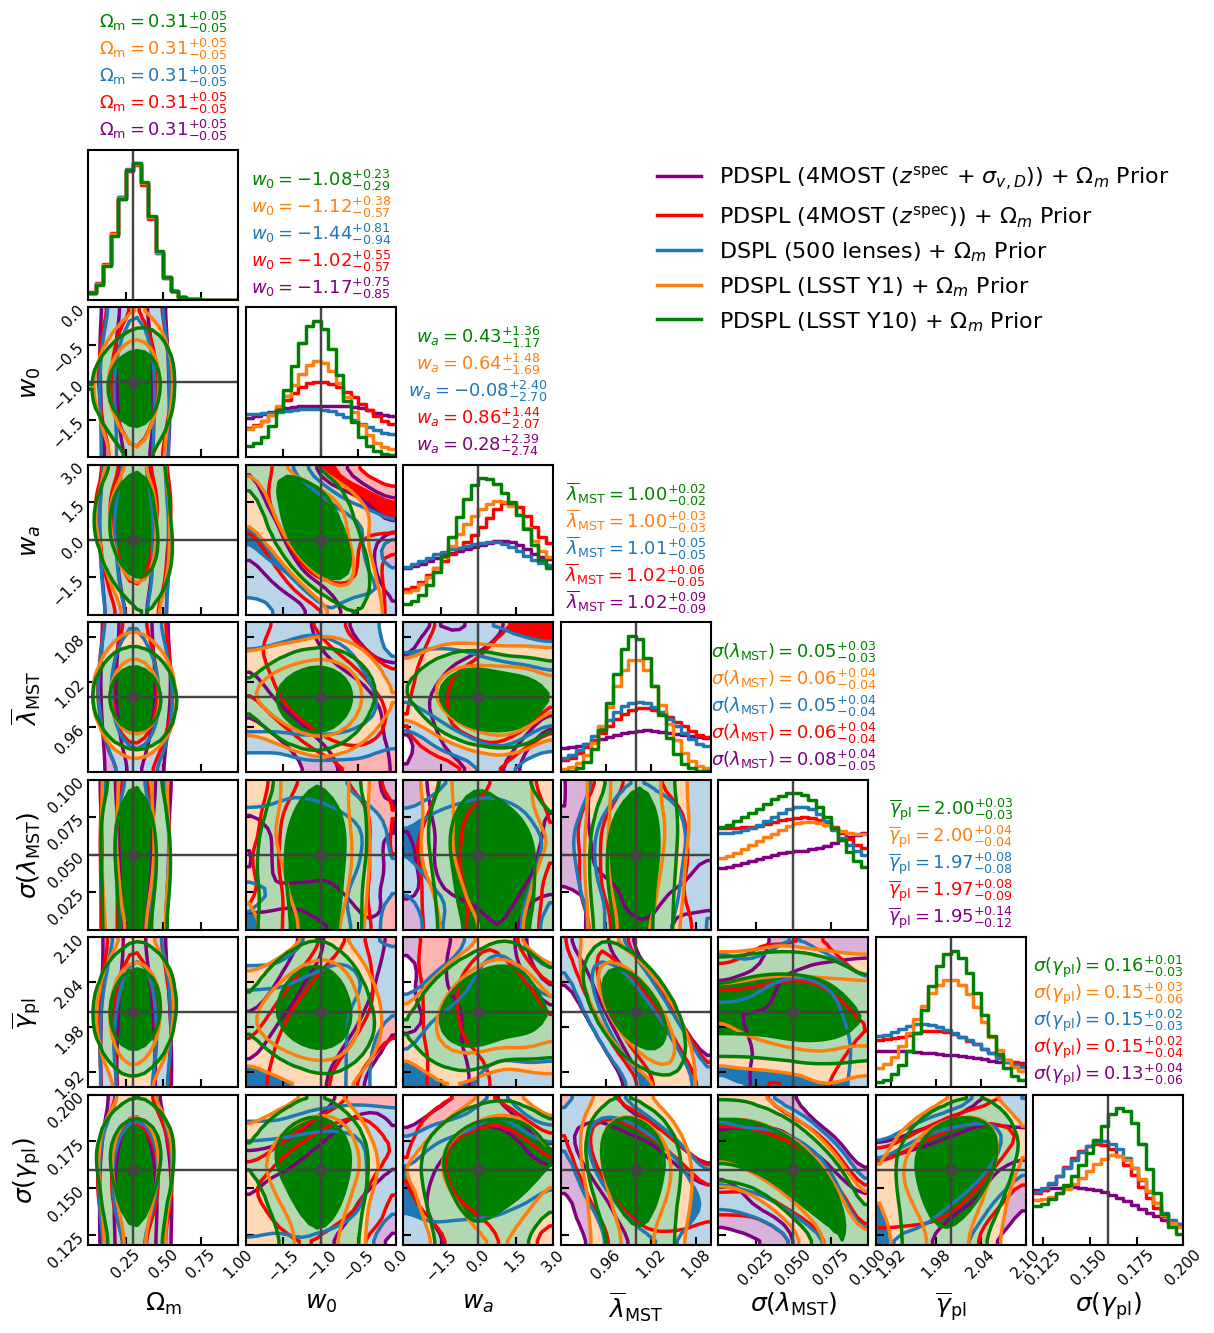

In [12]:
scenarios_to_plot = [
    'lsst_4most_spec-z_sigma_v_om_prior',
    'lsst_4most_spec-z_om_prior', 
    'DSPL_om_prior', 
    'lsst_y1_om_prior', 
    'lsst_y10_om_prior'
]

fig = plot_dspl_corner(
    scenarios=scenarios, 
    truth=truth, 
    fixed_params=fixed_params, 
    scenarios_to_plot=scenarios_to_plot,
    custom_ranges=custom_ranges,
    latex_labels=latex_labels,
    figsize=(12, 12),
    show_multiple_titles=True
)

plt.show()

###  d. DSPL, LSST Y1, and LSST Y10 Corner Plot -- $\Omega_m$ Prior

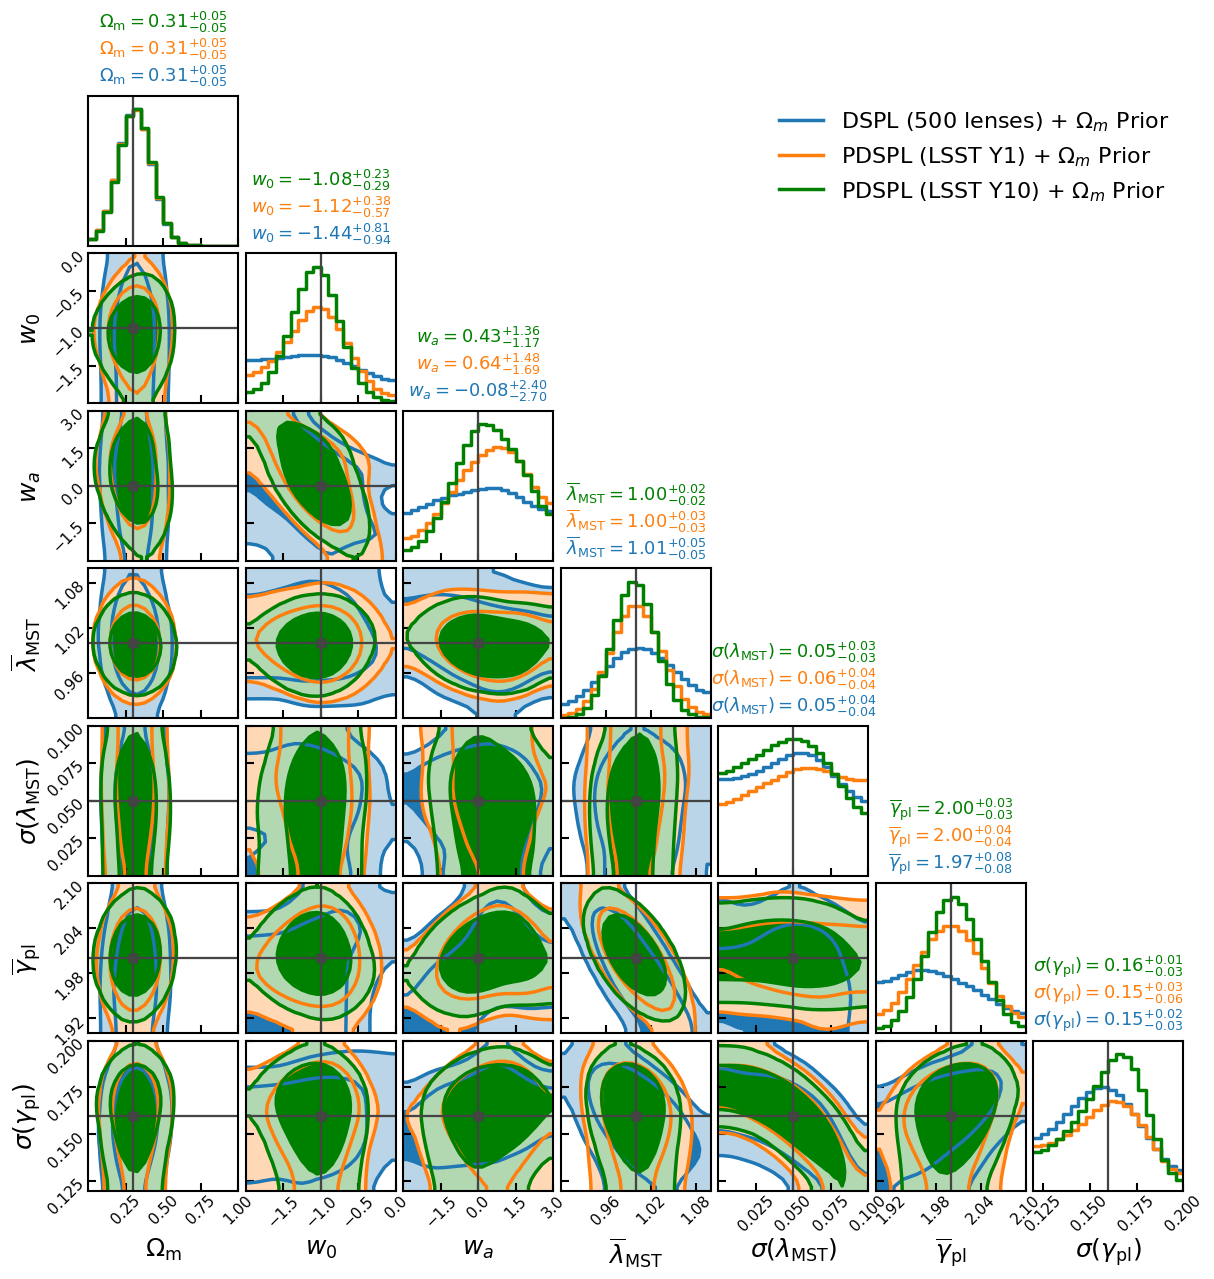

In [13]:
scenarios_to_plot = [
    'DSPL_om_prior', 
    'lsst_y1_om_prior', 
    'lsst_y10_om_prior'
]

fig = plot_dspl_corner(
    scenarios=scenarios, 
    truth=truth, 
    fixed_params=fixed_params, 
    scenarios_to_plot=scenarios_to_plot,
    custom_ranges=custom_ranges,
    latex_labels=latex_labels,
    figsize=(12, 12),
    show_multiple_titles=True
)

plt.show()

###  e. LSST Y10 Corner Plot -- With and Without $\Omega_m$ Prior

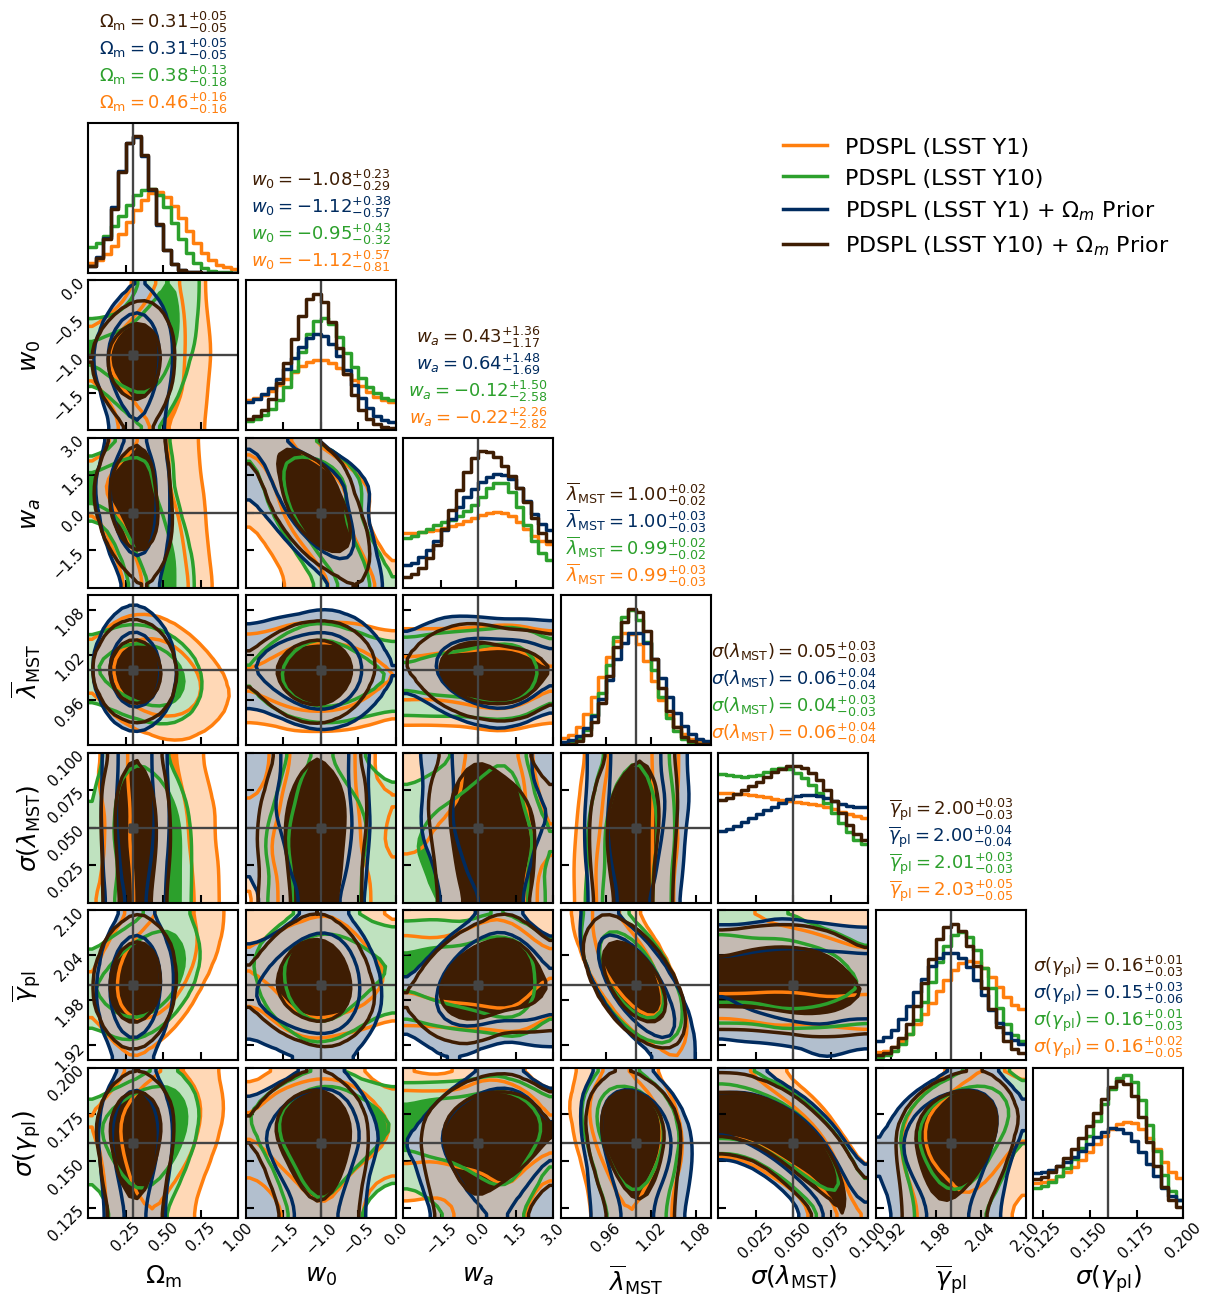

In [14]:
scenarios_to_plot = [
    'lsst_y1',
    'lsst_y10',
    'lsst_y1_om_prior', 
    'lsst_y10_om_prior'
]

custom_colors_dict = {
    'lsst_y1': '#ff7f0e',
    'lsst_y10': '#2ca02c',
    'lsst_y1_om_prior': "#002B5F",
    'lsst_y10_om_prior': "#3e1d03"
}

fig = plot_dspl_corner(
    scenarios=scenarios, 
    truth=truth, 
    fixed_params=fixed_params, 
    scenarios_to_plot=scenarios_to_plot,
    custom_ranges=custom_ranges,
    latex_labels=latex_labels,
    figsize=(12, 12),
    show_multiple_titles=True,
    custom_colors_dict=custom_colors_dict
)

plt.show()

###  f. LSST Y10 vs DSPL Corner Plot -- With and Without $\Omega_m$ Prior

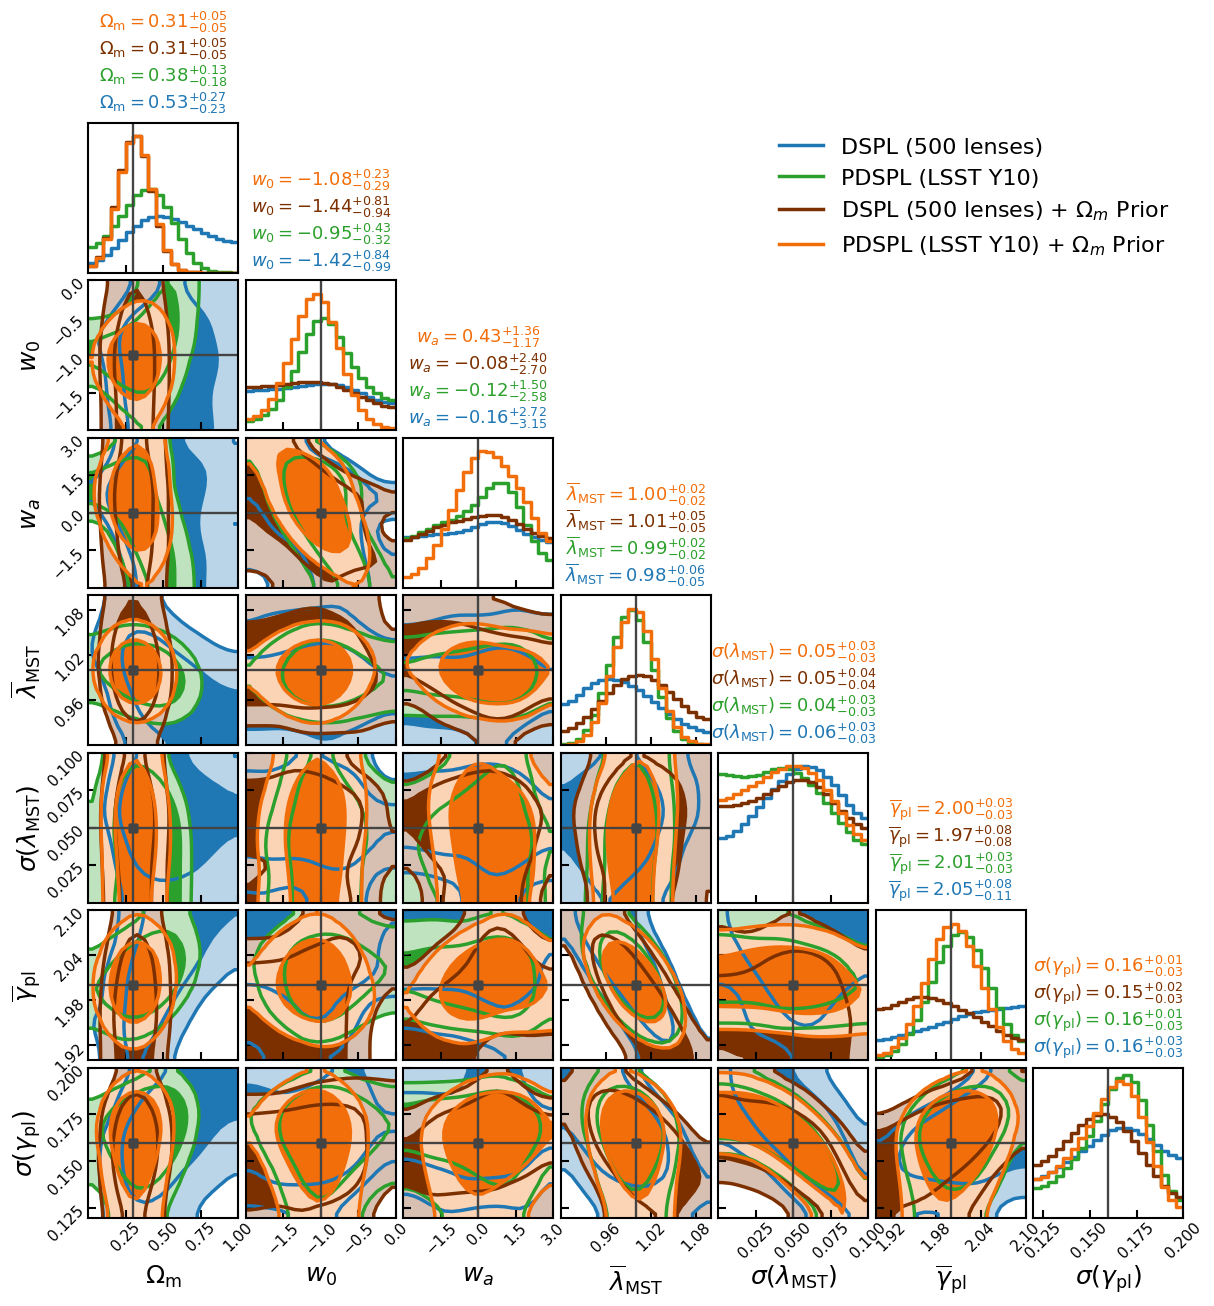

In [15]:
scenarios_to_plot = [
    'DSPL',
    'lsst_y10',
    'DSPL_om_prior', 
    'lsst_y10_om_prior'
]

custom_colors_dict = {
    'DSPL': '#1f77b4',
    'lsst_y10': '#2ca02c',
    'DSPL_om_prior': "#7c3000",
    'lsst_y10_om_prior': "#f26e0a"
}

fig = plot_dspl_corner(
    scenarios=scenarios, 
    truth=truth, 
    fixed_params=fixed_params, 
    scenarios_to_plot=scenarios_to_plot,
    custom_ranges=custom_ranges,
    latex_labels=latex_labels,
    figsize=(12, 12),
    show_multiple_titles=True,
    custom_colors_dict=custom_colors_dict,
    save_path=FIGURE_DIRECTORY + "/pdspls_vs_DSPL_w0waCDM_scatter_forecast.pdf"
)

plt.show()

### g. All PDSPLs Corner Plot -- Uniform Priors

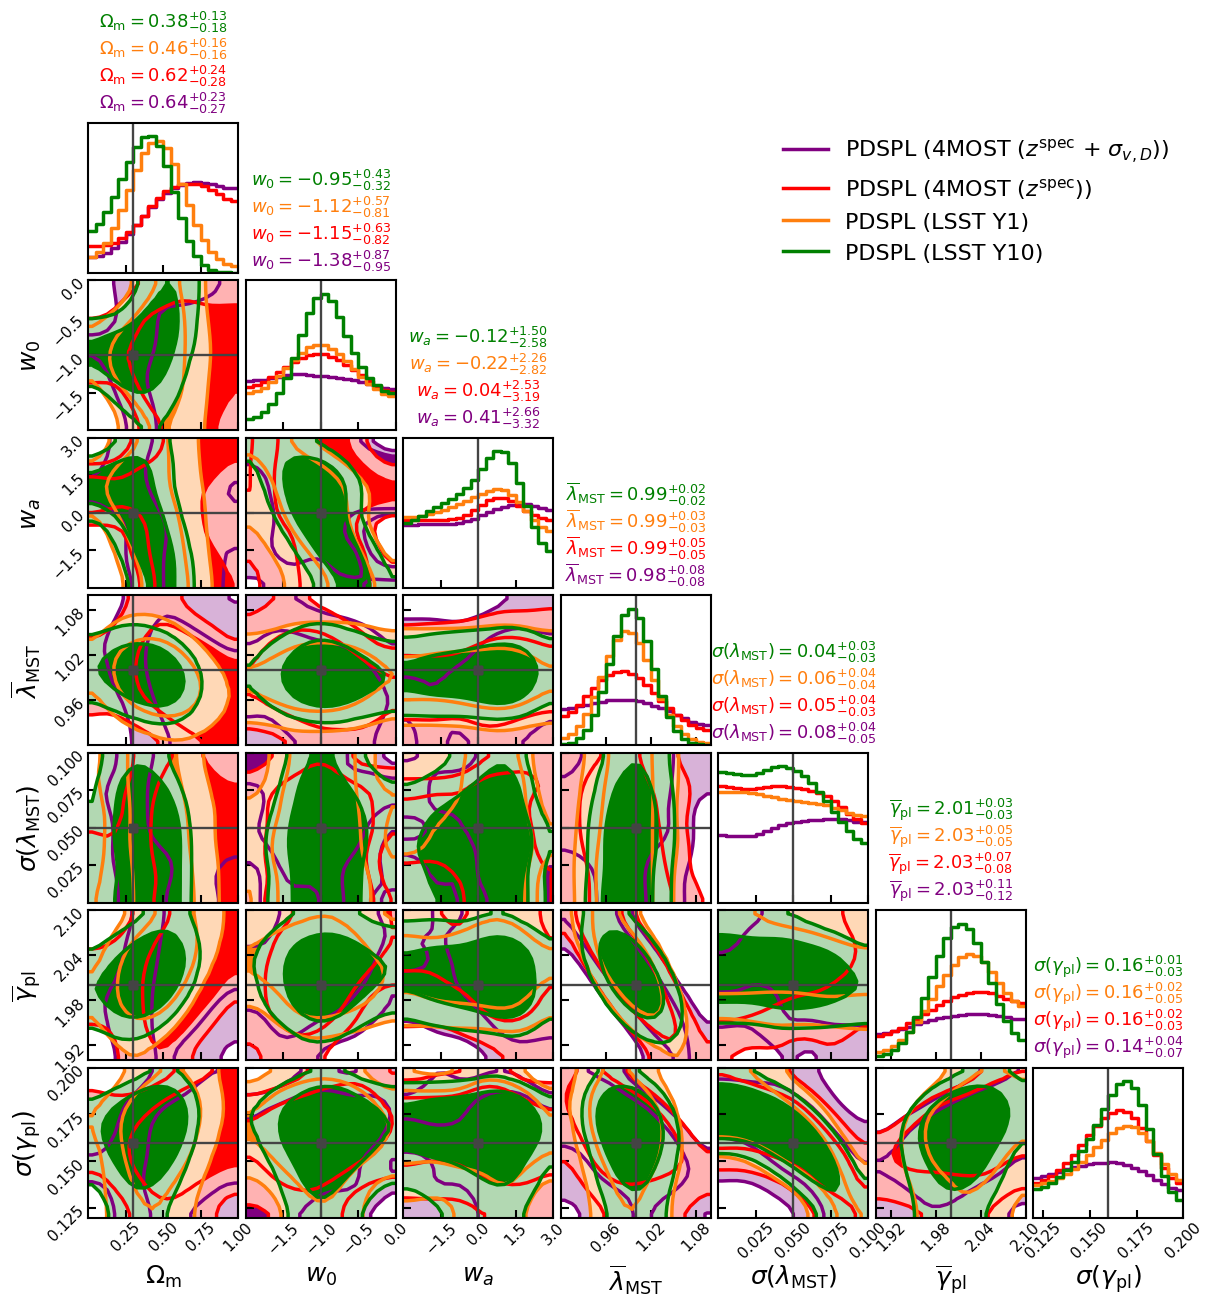

In [16]:
scenarios_to_plot = [
    'lsst_4most_spec-z_sigma_v',
    'lsst_4most_spec-z',
    'lsst_y1', 
    'lsst_y10'
]

fig = plot_dspl_corner(
    scenarios=scenarios, 
    truth=truth, 
    fixed_params=fixed_params, 
    scenarios_to_plot=scenarios_to_plot,
    custom_ranges=custom_ranges,
    latex_labels=latex_labels,
    figsize=(12, 12),
    show_multiple_titles=True,
    save_path=FIGURE_DIRECTORY + "/pdspls_w0waCDM_scatter_forecast.pdf"
)

plt.show()

## Table of All Forecast Results

In [17]:
# ── Cell 9: Parameter summary table ──────────────────────────────────────────
print("\n--- Median ± 1σ Parameter Summary ---")
print(f"{'Scenario':<80} | {'Parameter':<30} | {'Median':>10} | {'-1σ':>10} | {'+1σ':>10}")
print("-" * 150)
for key, sc in scenarios.items():
    if "samples" not in sc:
        continue
    for p_idx, p_key in enumerate(param_labels):
        q16, q50, q84 = np.percentile(sc["samples"][:, p_idx], [16, 50, 84])
        print(f"{sc['name']:<80} | {p_key:<30} | {q50:>10.3f} | {q50-q16:>10.3f} | {q84-q50:>10.3f}")


--- Median ± 1σ Parameter Summary ---
Scenario                                                                         | Parameter                      |     Median |        -1σ |        +1σ
------------------------------------------------------------------------------------------------------------------------------------------------------
PDSPL (LSST Y1)                                                                  | $\Omega_m$                     |      0.460 |      0.162 |      0.156
PDSPL (LSST Y1)                                                                  | $w_0$                          |     -1.118 |      0.814 |      0.568
PDSPL (LSST Y1)                                                                  | $w_a$                          |     -0.221 |      2.821 |      2.260
PDSPL (LSST Y1)                                                                  | $\bar{\lambda}_{\rm int}$      |      0.990 |      0.027 |      0.028
PDSPL (LSST Y1)                              

## Latex Table of All Forecast Results

In [19]:
import numpy as np

# --- Helper to format MCMC constraints into LaTeX strings ---
def format_latex_constraint(samples, decimals=2):
    q16, q50, q84 = np.percentile(samples, [16, 50, 84])
    lower_err = q50 - q16
    upper_err = q84 - q50
    
    # If the errors are symmetric within 10%, use \pm
    if abs(upper_err - lower_err) / max(upper_err, lower_err) < 0.1:
        avg_err = (upper_err + lower_err) / 2.0
        return f"${q50:.{decimals}f} \\pm {avg_err:.{decimals}f}$"
    else:
        return f"${q50:.{decimals}f}^{{+{upper_err:.{decimals}f}}}_{{-{lower_err:.{decimals}f}}}$"

# --- Configuration ---
# The order of parameters in your MCMC chains
sampled_params = ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']

# Number of decimal places for each parameter respectively
decimal_places = [2, 2, 2, 3, 3, 3, 3]

# Map your scenario keys to the desired LaTeX display names
latex_row_names = {
    'DSPL': 'DSPL (500 lenses)',
    'lsst_y10': 'PDSPL (LSST Y10)',
    'lsst_4most_spec-z': 'PDSPL (4MOST $z^{\\rm spec}$)',
    'lsst_4most_spec-z_sigma_v': 'PDSPL (4MOST $z^{\\rm spec}$ + $\\sigma_v$)',
    'joint_PDSPL': 'Joint PDSPL',
    'joint_PDSPL_DSPL': 'Joint DSPL + PDSPL'
}

# --- Generate Table ---
print("\\begin{tabular}{l" + "c" * len(sampled_params) + "}")
print("\\toprule")
print("Sample & $\\Omega_{\\rm m}$ & $w_0$ & $w_a$ & $\\overline\\lambda_{\\rm int}$ & $\\sigma(\\lambda_{\\rm int})$ & $\\overline\\gamma_{\\rm pl}$ & $\\sigma(\\gamma_{\\rm pl})$ \\\\")
print("\\midrule")

# 1. Uniform Prior Block
print("\\multicolumn{8}{l}{\\textbf{Flat $w_0w_a$CDM}} \\\\")
print("\\midrule")
for key, row_name in latex_row_names.items():
    if key in scenarios and 'samples' in scenarios[key]:
        samples = scenarios[key]['samples']
        cols = [row_name]
        for p_idx, _ in enumerate(sampled_params):
            cols.append(format_latex_constraint(samples[:, p_idx], decimals=decimal_places[p_idx]))
        print(" & ".join(cols) + " \\\\")

print("\\midrule")

# 2. Omega_m Prior Block
print("\\multicolumn{8}{l}{\\textbf{Flat $w_0w_a$CDM + $\\Omega_{m}$ prior$^\\dagger$}} \\\\")
print("\\midrule")
for key, row_name in latex_row_names.items():
    key_prior = key + '_om_prior'
    if key_prior in scenarios and 'samples' in scenarios[key_prior]:
        samples = scenarios[key_prior]['samples']
        cols = [row_name]
        for p_idx, _ in enumerate(sampled_params):
            cols.append(format_latex_constraint(samples[:, p_idx], decimals=decimal_places[p_idx]))
        print(" & ".join(cols) + " \\\\")

print("\\bottomrule")
print("\\end{tabular}")

\begin{tabular}{lccccccc}
\toprule
Sample & $\Omega_{\rm m}$ & $w_0$ & $w_a$ & $\overline\lambda_{\rm int}$ & $\sigma(\lambda_{\rm int})$ & $\overline\gamma_{\rm pl}$ & $\sigma(\gamma_{\rm pl})$ \\
\midrule
\multicolumn{8}{l}{\textbf{Flat $w_0w_a$CDM}} \\
\midrule
DSPL (500 lenses) & $0.53^{+0.27}_{-0.23}$ & $-1.42^{+0.84}_{-0.99}$ & $-0.16^{+2.72}_{-3.15}$ & $0.977^{+0.060}_{-0.049}$ & $0.059 \pm 0.033$ & $2.050^{+0.084}_{-0.108}$ & $0.163^{+0.026}_{-0.034}$ \\
PDSPL (LSST Y10) & $0.38^{+0.13}_{-0.18}$ & $-0.95^{+0.43}_{-0.32}$ & $-0.12^{+1.50}_{-2.58}$ & $0.994 \pm 0.020$ & $0.045 \pm 0.032$ & $2.014 \pm 0.032$ & $0.163^{+0.014}_{-0.028}$ \\
PDSPL (4MOST $z^{\rm spec}$) & $0.62^{+0.24}_{-0.28}$ & $-1.15^{+0.63}_{-0.82}$ & $0.04^{+2.53}_{-3.19}$ & $0.987^{+0.053}_{-0.046}$ & $0.051 \pm 0.036$ & $2.027^{+0.069}_{-0.081}$ & $0.160^{+0.019}_{-0.030}$ \\
PDSPL (4MOST $z^{\rm spec}$ + $\sigma_v$) & $0.64^{+0.23}_{-0.27}$ & $-1.38 \pm 0.91$ & $0.41^{+2.66}_{-3.32}$ & $0.983 \pm 0.082$ & $0.

In [18]:
# ── Cell 10: Save ────────────────────────────────────────────────────────────
with open("../data/samples/forecast_scenarios_w0waCDM_fixed_scatter.pkl", "wb") as f:
    pickle.dump(scenarios, f)
print("Saved forecast_scenarios_w0waCDM_fixed_scatter.pkl")

Saved forecast_scenarios_w0waCDM_fixed_scatter.pkl


## Experiment 1 - Effect of Photometric Redshift Uncertainties on Forecasts


SCENARIO                                                     | N_LENS     | STATUS
-------------------------------------------------------------------------------------
PDSPL (LSST Y10) $\sigma_z = 0.00(1+z)$                      | 200        | GENERATED
PDSPL (LSST Y10) $\sigma_z = 0.01(1+z)$                      | 200        | GENERATED
PDSPL (LSST Y10) $\sigma_z = 0.02(1+z)$                      | 200        | GENERATED
PDSPL (LSST Y10) $\sigma_z = 0.03(1+z)$                      | 200        | GENERATED
PDSPL (LSST Y10) $\sigma_z = 0.05(1+z)$                      | 200        | GENERATED

--- MCMC for photo-z sensitivity ---

Running: PDSPL (LSST Y10) $\sigma_z = 0.00(1+z)$
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c0', 'beta_c1', 'beta_c2']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']


100%|██████████| 2000/2000 [03:20<00:00,  9.97it/s]



Running: PDSPL (LSST Y10) $\sigma_z = 0.01(1+z)$
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c0', 'beta_c1', 'beta_c2']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']


100%|██████████| 2000/2000 [03:19<00:00, 10.04it/s]



Running: PDSPL (LSST Y10) $\sigma_z = 0.02(1+z)$
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c0', 'beta_c1', 'beta_c2']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']


100%|██████████| 2000/2000 [03:17<00:00, 10.15it/s]



Running: PDSPL (LSST Y10) $\sigma_z = 0.03(1+z)$
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c0', 'beta_c1', 'beta_c2']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']


100%|██████████| 2000/2000 [03:16<00:00, 10.18it/s]



Running: PDSPL (LSST Y10) $\sigma_z = 0.05(1+z)$
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c0', 'beta_c1', 'beta_c2']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']


100%|██████████| 2000/2000 [03:13<00:00, 10.32it/s]


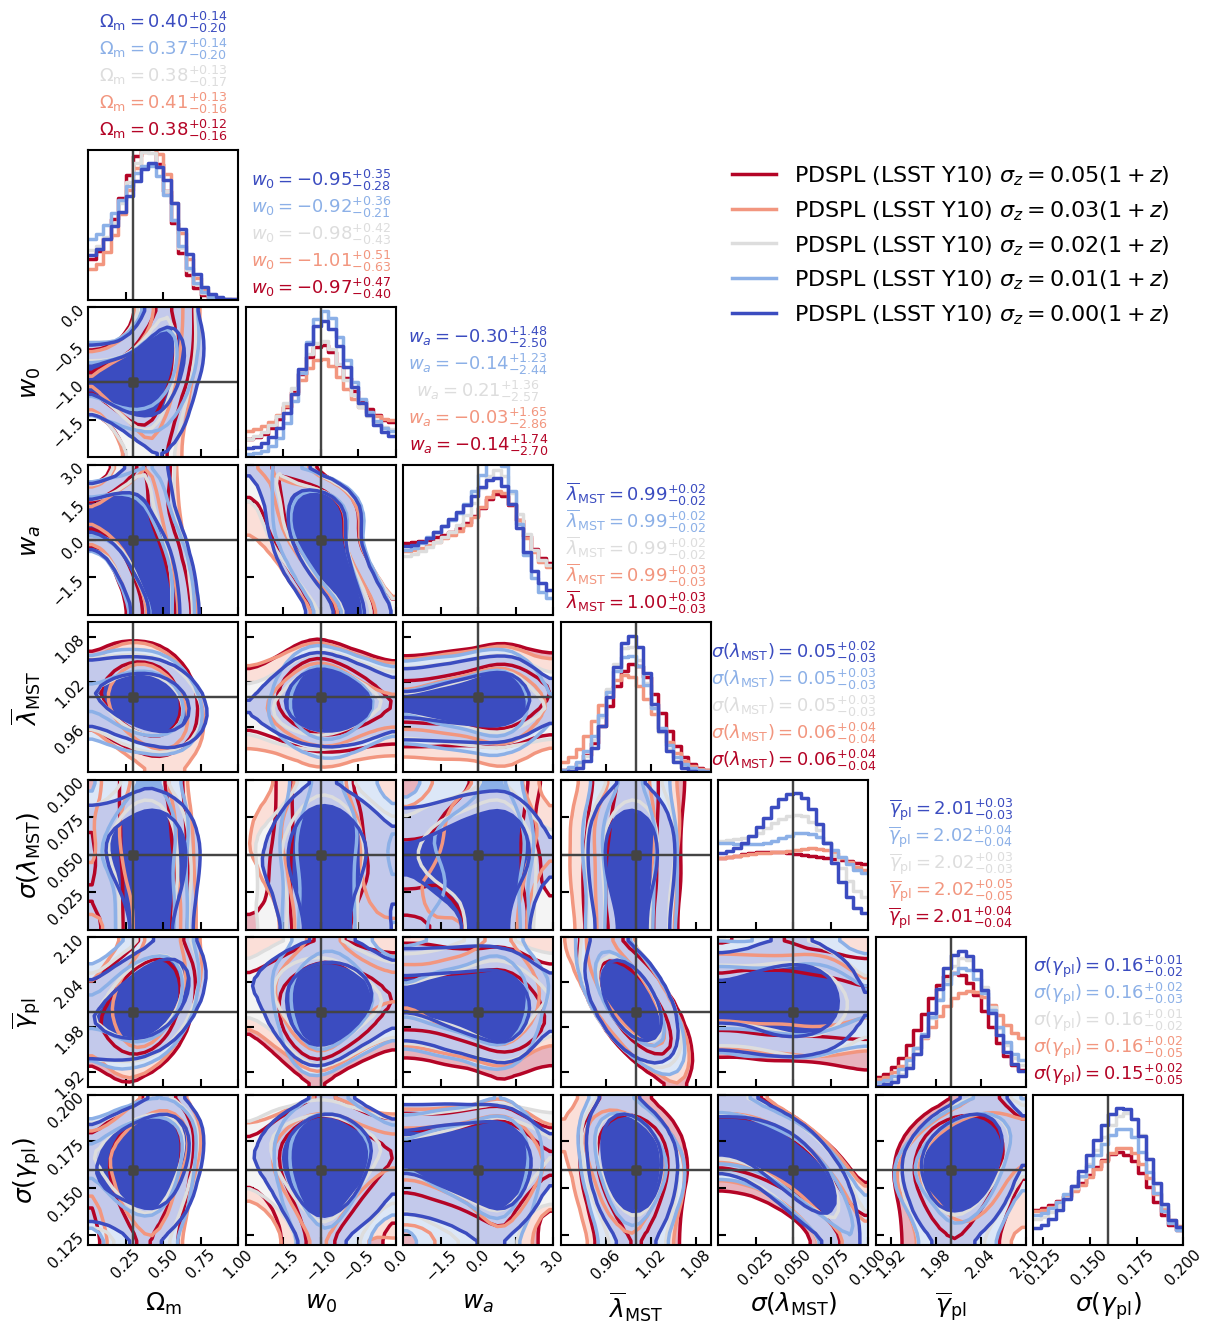

In [20]:
# ── Cell 11: Photo-z sensitivity experiment (LSST Y10 only) ──────────────────
scenarios_z_err = {}
for rel_z_error in [0.00, 0.01, 0.02, 0.03, 0.05]:
    key        = "lsst_y10"
    key_long   = key + f"_z_error_{rel_z_error:.2f}"
    pa         = pdspl_samples[key]["pairs_analysis"]
    scenarios_z_err[key_long] = {
        "name":                    (f"PDSPL ({pdspl_samples[key]['name']})"
                                    f" $\\sigma_z = {rel_z_error:.2f}(1+z)$"),
        "down_sampling":           len(pa["pairs_table"]) / 200,
        "num_lenses":              len(pa["pairs_table"]),
        "color":                   pdspl_samples[key]["color"],
        "coeffs":                  pa["scatter_vs_dissimilarity_fit_coeffs"],
        "fit_type":                pa["scatter_vs_dissimilarity_fit_type"],
        "pairs_table":             pa["pairs_table"],
        "pairs_table_with_errors": pa["pairs_table_with_errors"],
        "sigma_beta":              pa["scatter_in_beta_E"],
        "redshift_error_rel":      rel_z_error,
        "backend_path":            None,
    }

print(f"\n{'SCENARIO':<60} | {'N_LENS':<10} | STATUS")
print("-" * 85)
for key_long, sc in scenarios_z_err.items():
    num_samples  = int(sc["num_lenses"] / sc["down_sampling"])
    kwargs_list  = []
    coeffs       = sc["coeffs"]
    fit_type     = sc["fit_type"]
    random_idx   = np.random.choice(len(sc["pairs_table"]), size=num_samples, replace=False)

    for i in random_idx:
        z_lens        = sc["pairs_table"]["z_D"][i]
        z1            = sc["pairs_table"]["z_S1"][i]
        z2            = sc["pairs_table"]["z_S2"][i]
        dissimilarity = sc["pairs_table_with_errors"]["dissimilarity"][i]

        sigma_beta_intrinsic = eval_scatter_model(coeffs, fit_type, dissimilarity)
        sigma_meas_rel = np.sqrt(0.01 ** 2 + 0.01 ** 2)

        kwargs_list.append(draw_lens_from_given_zs(
            z_lens=z_lens, z1=z1, z2=z2,
            lambda_mst_mean=truth["lambda_int"], lambda_mst_sigma=truth["lambda_sigma"],
            gamma_pl_mean=truth["gamma_pl"],     gamma_pl_sigma=truth["gamma_sigma"],
            sigma_beta_intrinsic=sigma_beta_intrinsic,
            sigma_meas_rel=sigma_meas_rel,
            dissimilarity=dissimilarity,
            down_sampling=sc["down_sampling"],
            with_noise=False,
            cosmo=cosmo_true,
            redshift_error_rel=sc["redshift_error_rel"],
        ))
    sc["kwargs_list"] = kwargs_list
    print(f"{sc['name']:<60} | {num_samples:<10} | GENERATED")

print("\n--- MCMC for photo-z sensitivity ---")
for key_long, sc in scenarios_z_err.items():
    if "kwargs_list" not in sc:
        continue
    print(f"\nRunning: {sc['name']}")

    coeffs = sc["coeffs"]
    fixed_params_sc = fixed_params.copy()
    fixed_params_sc["beta_c0"] = coeffs[1]
    fixed_params_sc["beta_c1"] = coeffs[0]
    fixed_params_sc["beta_c2"] = 0.0

    samples, _ = run_dspl_inference(
        sc["kwargs_list"],
        n_walkers=64, n_steps=2000, n_burn=500,
        initial_guess=my_guess,
        fixed_params=fixed_params_sc,
        initial_scatter=my_spreads,
        priors=my_priors,
        backend_path=sc["backend_path"],
    )
    sc["samples"] = samples

custom_colors_z = {
    "lsst_y10_z_error_0.00": "#3b4cc0",
    "lsst_y10_z_error_0.01": "#8cb0e7",
    "lsst_y10_z_error_0.02": "#dddddd",
    "lsst_y10_z_error_0.03": "#f2967f",
    "lsst_y10_z_error_0.05": "#b40426",
}
fig = plot_dspl_corner(
    scenarios=scenarios_z_err, truth=truth, fixed_params=fixed_params,
    scenarios_to_plot=list(reversed(list(scenarios_z_err.keys()))),
    custom_ranges=custom_ranges, latex_labels=latex_labels, figsize=(12, 12),
    show_multiple_titles=True,
    custom_colors_dict=custom_colors_z,
)
plt.show()